# EDA & Pre-Processing

In [123]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score

## 1. Load Data

In [124]:
costumer = pd.read_csv("customer_info.csv")
costumer

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
0,3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,...,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
1,4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,...,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
2,5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,...,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
3,7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,...,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
4,8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,...,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33033,39996,Joshua Howard,male,05/16/1973 02:04 PM,0.0,0.0,2.0,1.0,475.0,13488.0,...,1154.0,62.0,1598.0,366.0,162.0,0.261352,2014.0,NaN,38.742306,-9.163971
33034,39997,Anthony Hines,male,05/10/1955 01:19 AM,1.0,0.0,1.0,1.0,8430.0,14408.0,...,602.0,220.0,2105.0,227.0,97.0,0.143479,2014.0,NaN,38.748505,-9.193445
33035,39998,Edna Hasselman,female,05/15/1945 11:09 PM,1.0,1.0,0.0,4.0,8029.0,1480.0,...,NaN,1719.0,89.0,258.0,206.0,0.181917,2012.0,NaN,38.776003,-9.137943
33036,39999,George Kramer,male,05/25/1951 09:02 PM,1.0,1.0,1.0,6.0,8364.0,3114.0,...,113.0,410.0,NaN,225.0,385.0,0.807259,2017.0,NaN,38.736034,-9.145235


In [125]:
costumer_basket = pd.read_csv("customer_basket.csv")
costumer_basket

,invoice_id,list_of_goods,customer_id
0,3700630,"['chicken', 'rice', 'pepper', 'whole wheat ric...",12912
1,10242376,"['low fat yogurt', 'tomatoes', 'pepper', 'aspa...",22853
2,91550,"['cake', 'tomatoes', 'pancakes', 'iPad', 'fina...",19
3,3137503,"['cereals', 'megaman zero', 'final fantasy XIX...",10995
4,7165061,"['rice', 'frozen smoothie', 'black tea', 'tea'...",27807
...,...,...,...
99995,7685930,"['yams', 'airpods', 'shrimp']",21357
99996,2998960,"['cake', 'chocolate bread', 'cologne', 'beer',...",7817
99997,4409376,"['chicken', 'frozen smoothie', 'milk', 'body s...",35497
99998,3650163,"['metroid fusion', 'cat food', 'melons', 'ring...",13412


## 2. Initial Inspection — customer_info

In [126]:
costumer.info()

<class 'pandas.DataFrame'>
RangeIndex: 33038 entries, 0 to 33037
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_id                              33038 non-null  int64  
 1   customer_name                            33038 non-null  str    
 2   customer_gender                          33038 non-null  str    
 3   customer_birthdate                       32873 non-null  str    
 4   kids_home                                32708 non-null  float64
 5   teens_home                               32708 non-null  float64
 6   number_complaints                        32377 non-null  float64
 7   distinct_stores_visited                  32708 non-null  float64
 8   lifetime_spend_groceries                 33038 non-null  float64
 9   lifetime_spend_electronics               32377 non-null  float64
 10  typical_hour                             32377 non-null  

In [127]:
costumer.isnull().sum()

customer_id                                    0
customer_name                                  0
customer_gender                                0
customer_birthdate                           165
kids_home                                    330
teens_home                                   330
number_complaints                            661
distinct_stores_visited                      330
lifetime_spend_groceries                       0
lifetime_spend_electronics                   661
typical_hour                                 661
lifetime_spend_vegetables                    661
lifetime_spend_nonalcohol_drinks               0
lifetime_spend_alcohol_drinks                330
lifetime_spend_meat                          661
lifetime_spend_fish                          991
lifetime_spend_hygiene                       330
lifetime_spend_videogames                    661
lifetime_spend_petfood                       661
lifetime_total_distinct_products               0
percentage_of_produc

In [128]:
costumer.duplicated().sum()

np.int64(0)

## 3. Initial Inspection — customer_basket

In [129]:
costumer_basket.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   invoice_id     100000 non-null  int64
 1   list_of_goods  100000 non-null  str  
 2   customer_id    100000 non-null  int64
dtypes: int64(2), str(1)
memory usage: 2.3 MB


In [130]:
costumer_basket.duplicated().sum()
# costumer_basket is okay, no nulls, no duplicates

np.int64(0)

## 4. Missing Values — MICE Imputation

In [131]:
missing_pct = costumer.isnull().sum() * 100 / len(costumer)
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

loyalty_card_number                        39.669472
lifetime_spend_fish                         2.999576
number_complaints                           2.000726
lifetime_spend_vegetables                   2.000726
lifetime_spend_meat                         2.000726
lifetime_spend_videogames                   2.000726
typical_hour                                2.000726
lifetime_spend_electronics                  2.000726
lifetime_spend_petfood                      2.000726
distinct_stores_visited                     0.998850
teens_home                                  0.998850
kids_home                                   0.998850
lifetime_spend_hygiene                      0.998850
lifetime_spend_alcohol_drinks               0.998850
percentage_of_products_bought_promotion     0.998850
customer_birthdate                          0.499425
dtype: float64


In [132]:
#The creation of two variables
current_year = datetime.now().year

# Convert birthdate to age
costumer['age'] = current_year - pd.to_datetime(costumer['customer_birthdate'], format='mixed').dt.year

# Binary flag for loyalty card
costumer['has_loyalty_card'] = costumer['loyalty_card_number'].notnull().astype(int)

# Columns excluded from MICE: non-numeric / identifiers / already-derived flags
cols_to_drop_for_mice = [
    'customer_id',
    'customer_name',
    'latitude',
    'longitude',
    'customer_birthdate',
    'loyalty_card_number'
]


# FIX: errors='ignore' avoids KeyError if any column was already dropped
cols_mice = costumer.drop(columns=cols_to_drop_for_mice, errors='ignore').select_dtypes(include='number').columns

imputer = IterativeImputer(max_iter=10, random_state=42)
costumer[cols_mice] = imputer.fit_transform(costumer[cols_mice])


print("Missing values after MICE:")
print(costumer.isnull().sum())

Missing values after MICE:
customer_id                                    0
customer_name                                  0
customer_gender                                0
customer_birthdate                           165
kids_home                                      0
teens_home                                     0
number_complaints                              0
distinct_stores_visited                        0
lifetime_spend_groceries                       0
lifetime_spend_electronics                     0
typical_hour                                   0
lifetime_spend_vegetables                      0
lifetime_spend_nonalcohol_drinks               0
lifetime_spend_alcohol_drinks                  0
lifetime_spend_meat                            0
lifetime_spend_fish                            0
lifetime_spend_hygiene                         0
lifetime_spend_videogames                      0
lifetime_spend_petfood                         0
lifetime_total_distinct_products          

`customer_birthdate` and `loyalty_card_number` will be removed later

## 5. Outlier Visualisation & Capping

Capping is applied only to **spend / behavioural** numeric columns —  
identifiers (`customer_id`), coordinates (`latitude`, `longitude`) and the  
binary/encoded columns are excluded.

In [133]:
# Columns that should NOT be capped
exclude_from_capping = [
    'customer_id', 'customer_gender', 'latitude', 'longitude', 'year_first_transaction','customer_birthdate']

cap_cols = [
    col for col in costumer.select_dtypes(include='number').columns
    if col not in exclude_from_capping
]

n_rows = math.ceil(len(cap_cols) / 3)

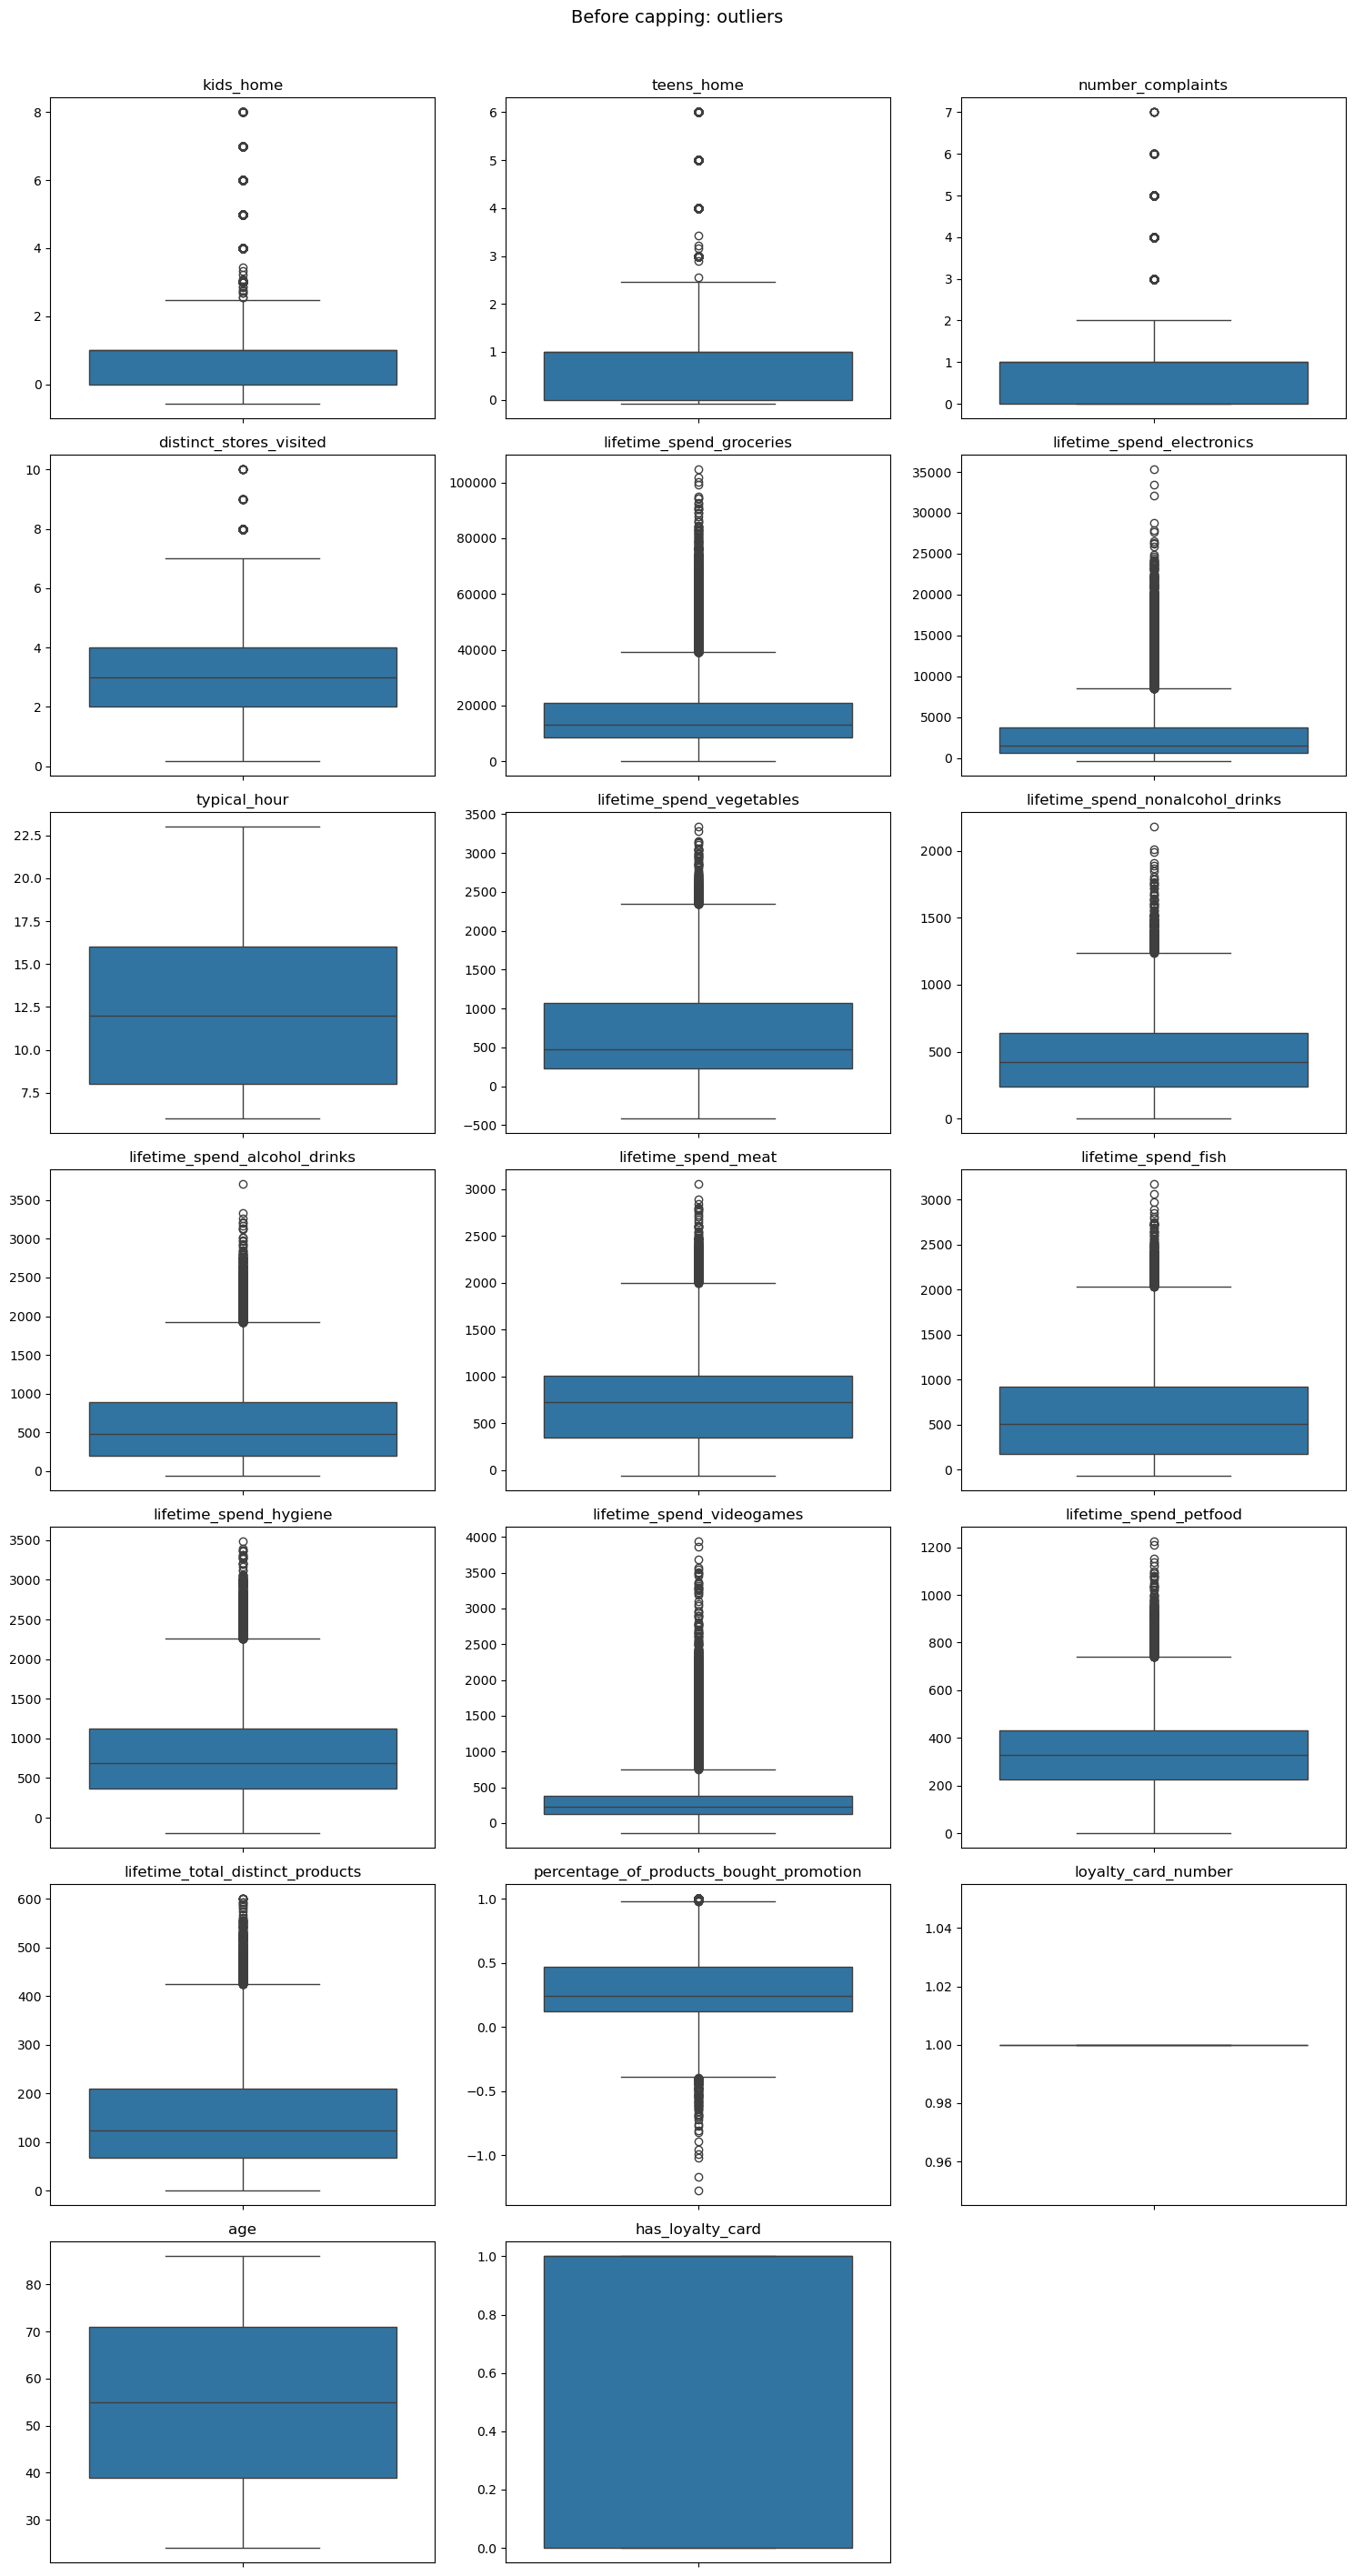

In [134]:
fig, axes = plt.subplots(n_rows, 3, figsize=(15, n_rows * 4))
axes = axes.flatten()
for i, col in enumerate(cap_cols):
    sns.boxplot(y=costumer[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel('')
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
# FIX: use fig.suptitle instead of plt.title for multi-subplot figures
fig.suptitle("Before capping: outliers", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [135]:
for col in cap_cols:
    Q1 = costumer[col].quantile(0.25)
    Q3 = costumer[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    costumer[col] = np.clip(costumer[col], lower, upper)

print("Outlier capping applied to:", cap_cols)

Outlier capping applied to: ['kids_home', 'teens_home', 'number_complaints', 'distinct_stores_visited', 'lifetime_spend_groceries', 'lifetime_spend_electronics', 'typical_hour', 'lifetime_spend_vegetables', 'lifetime_spend_nonalcohol_drinks', 'lifetime_spend_alcohol_drinks', 'lifetime_spend_meat', 'lifetime_spend_fish', 'lifetime_spend_hygiene', 'lifetime_spend_videogames', 'lifetime_spend_petfood', 'lifetime_total_distinct_products', 'percentage_of_products_bought_promotion', 'loyalty_card_number', 'age', 'has_loyalty_card']


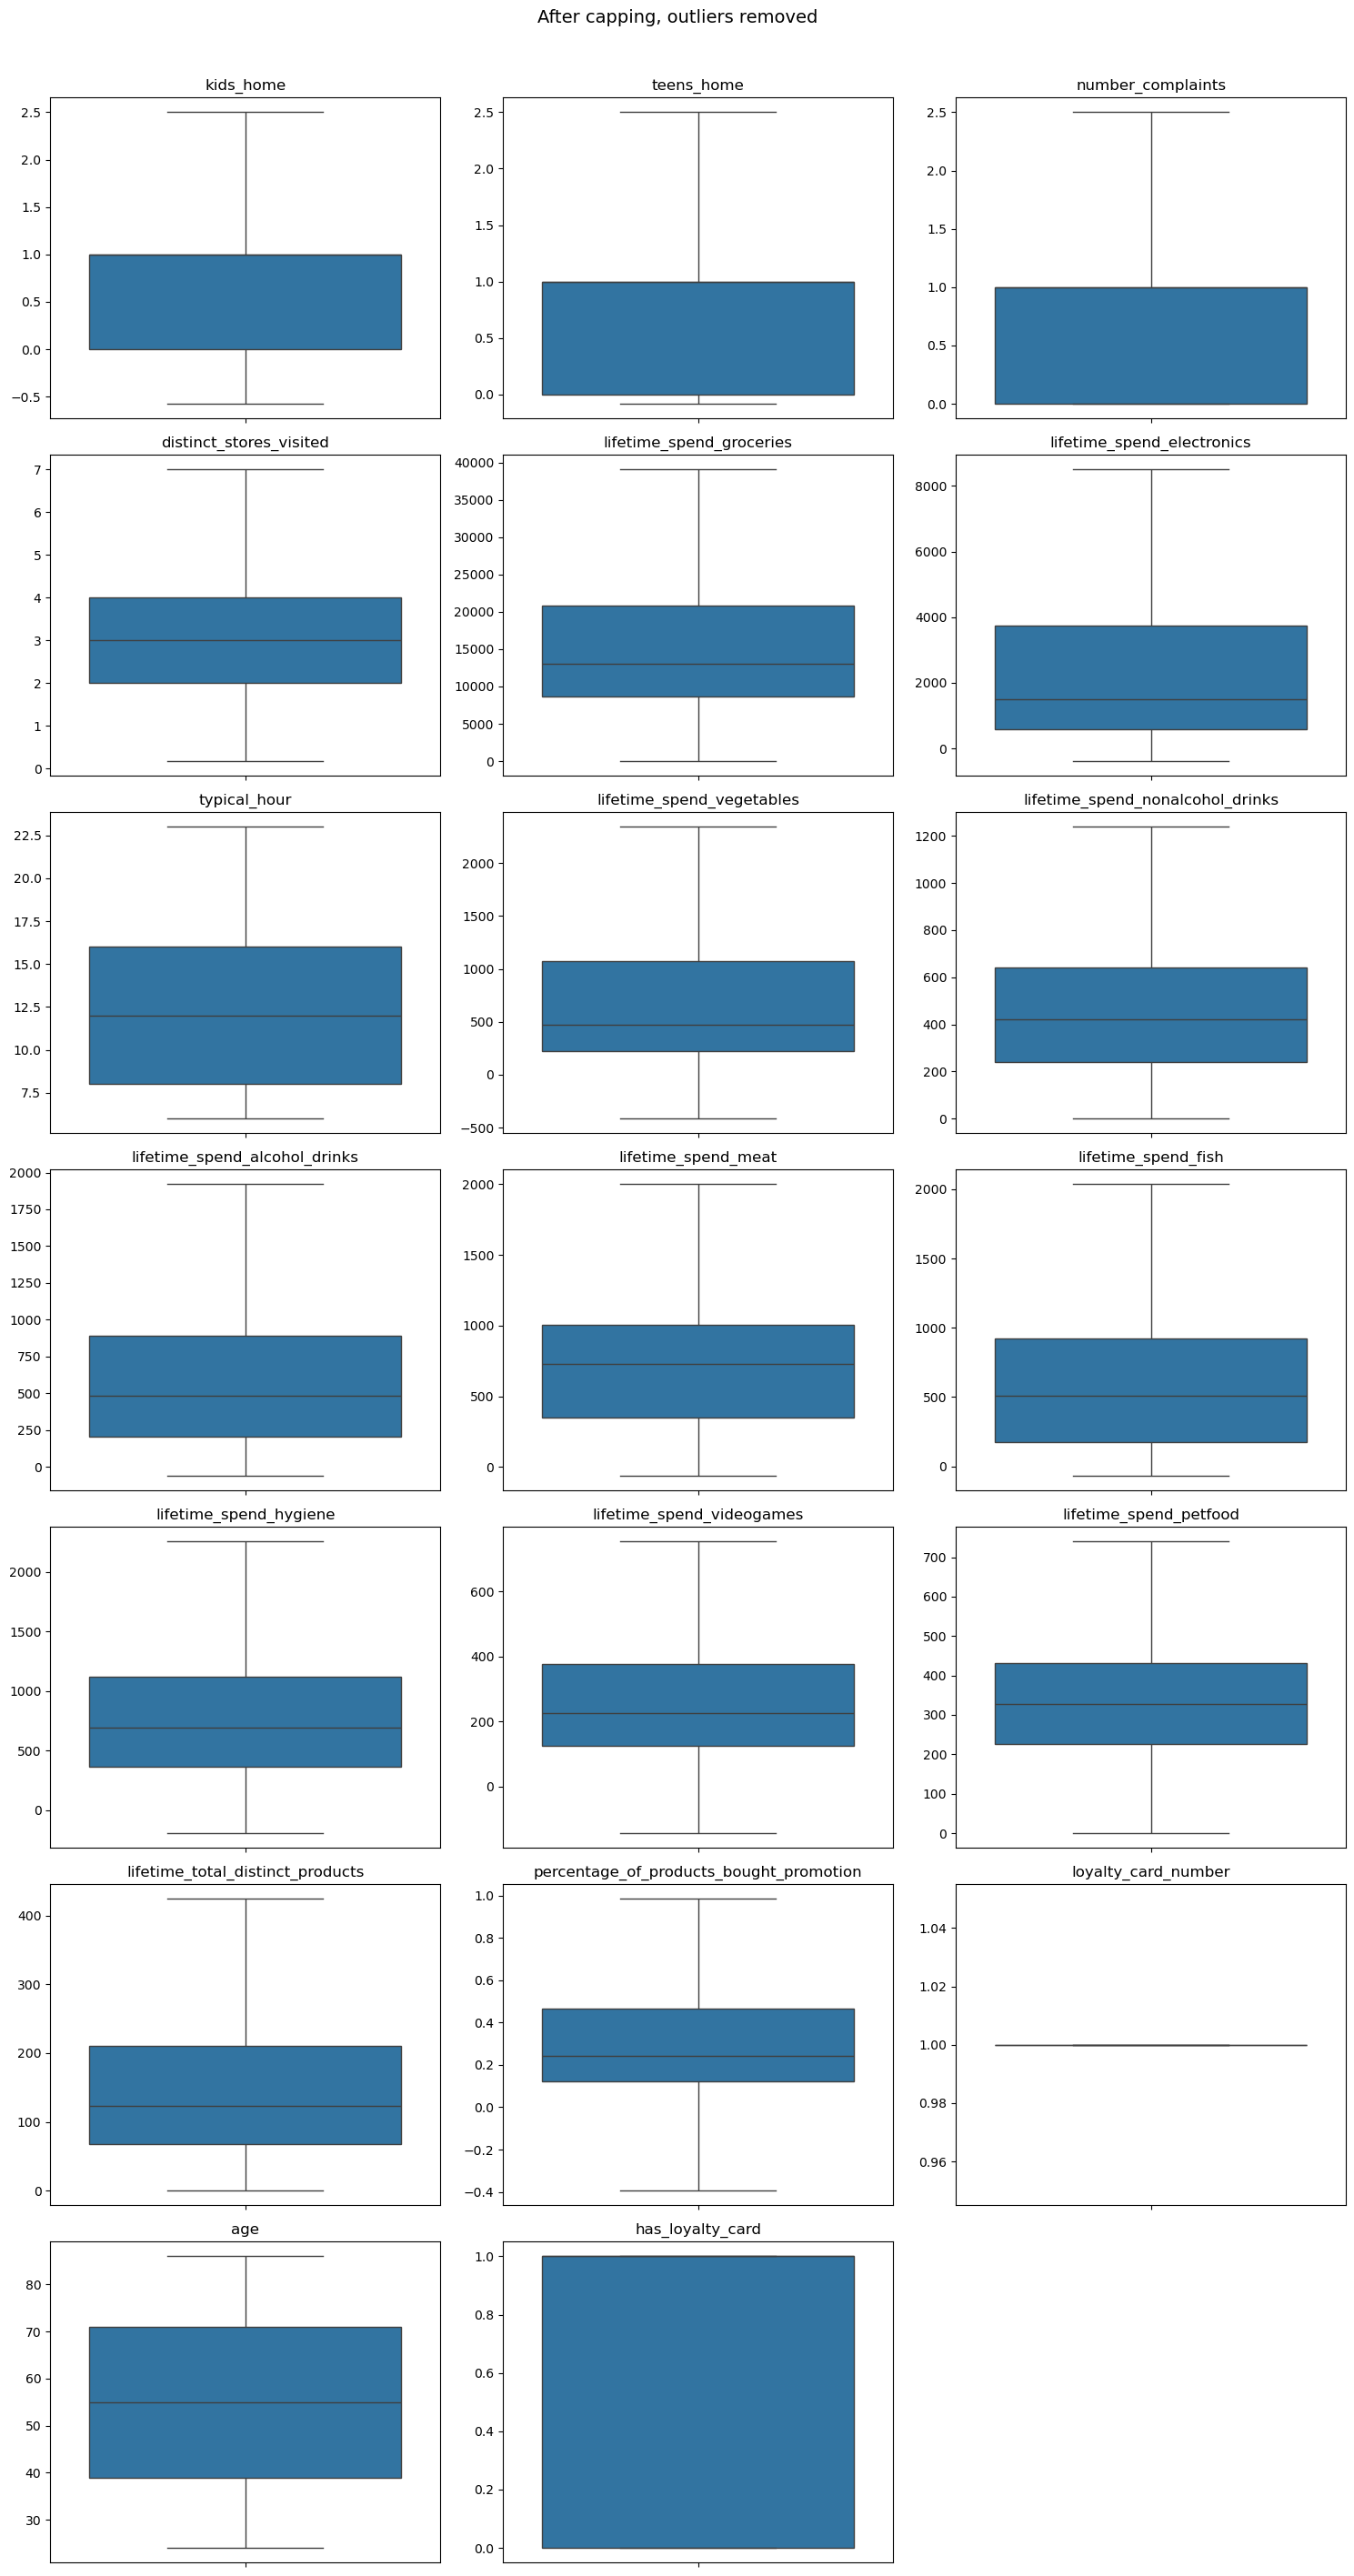

In [136]:
fig, axes = plt.subplots(n_rows, 3, figsize=(15, n_rows * 4))
axes = axes.flatten()
for i, col in enumerate(cap_cols):
    sns.boxplot(y=costumer[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel('')
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
# FIX: use fig.suptitle instead of plt.title
fig.suptitle("After capping, outliers removed", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Feature Engineering

In [137]:
# Convert first transaction year to seniority
costumer['years_as_customer'] = current_year - costumer['year_first_transaction']

# Encode gender — astype(str) guards against any unexpected NaN
le = LabelEncoder()
costumer['customer_gender'] = le.fit_transform(costumer['customer_gender'].astype(str))

# Combine 'kids_at_home' with 'teens_at_home'
costumer['dependents_home'] = costumer['kids_home'] + costumer['teens_home']

# Create spend collumns
spend_cols = [col for col in costumer.columns if 'lifetime_spend_' in col]

costumer['total_spend'] = costumer[spend_cols].sum(axis=1)

for col in spend_cols:
    pct_name = col.replace('lifetime_spend_', 'pct_')
    costumer[pct_name] = costumer[col] / (costumer['total_spend'] + 0.0001)

# Drop non-predictive columns
cols_to_drop = ['customer_id', 'customer_name','customer_gender', 'customer_birthdate', 'latitude', 'longitude',
                'number_complaints', 'distinct_stores_visited','typical_hour', 'loyalty_card_number', 'kids_home', 'teens_home',
                'lifetime_total_distinct_products','lifetime_spend_vegetables', 'lifetime_spend_nonalcohol_drinks',
                'lifetime_spend_alcohol_drinks','lifetime_spend_meat','lifetime_spend_fish','lifetime_spend_hygiene',
                'lifetime_spend_videogames','lifetime_spend_petfood','lifetime_total_distinct_products']

costumer = costumer.drop(columns=cols_to_drop, errors='ignore')


## 7. Scale & Export

In [138]:
costumer

,lifetime_spend_groceries,lifetime_spend_electronics,percentage_of_products_bought_promotion,year_first_transaction,age,has_loyalty_card,years_as_customer,dependents_home,total_spend,pct_groceries,pct_electronics,pct_vegetables,pct_nonalcohol_drinks,pct_alcohol_drinks,pct_meat,pct_fish,pct_hygiene,pct_videogames,pct_petfood
0,11731.0,4553.000,0.631599,2020.0,56.0,1.0,6.0,2.0,18590.000000,0.631038,0.244917,0.020065,0.017375,0.009521,0.001506,0.011458,0.029693,0.013771,0.020656
1,13694.0,963.000,0.149890,2013.0,51.0,1.0,13.0,1.0,20233.000000,0.676815,0.047596,0.099442,0.026343,0.004695,0.002125,0.000741,0.092918,0.016458,0.032867
2,12407.0,0.000,0.069126,2005.0,55.0,0.0,21.0,0.0,15549.000000,0.797929,0.000000,0.035694,0.006496,0.007589,0.081356,0.017557,0.032607,0.006496,0.014277
3,7493.0,1105.000,0.253609,2021.0,44.0,1.0,5.0,0.0,14049.429887,0.533331,0.078651,0.005979,0.053881,0.080644,0.069184,0.077085,0.034521,0.053627,0.013097
4,9187.0,8499.375,0.186569,2021.0,57.0,1.0,5.0,0.0,22950.804887,0.400291,0.370330,0.016557,0.025794,0.031284,0.046534,0.044225,0.012941,0.032828,0.019215
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33033,475.0,8499.375,0.261352,2014.0,53.0,0.0,12.0,0.0,14086.804887,0.033719,0.603357,0.013488,0.040676,0.070562,0.072408,0.081921,0.004401,0.053485,0.025982
33034,8430.0,8499.375,0.143479,2014.0,71.0,0.0,12.0,1.0,22259.804887,0.378710,0.381826,0.013073,0.022327,0.063657,0.059434,0.027044,0.009883,0.033847,0.010198
33035,8029.0,1480.000,0.181917,2012.0,81.0,0.0,14.0,2.0,14341.108794,0.559859,0.103200,0.111567,0.034446,0.008158,0.021407,0.017301,0.119865,0.006206,0.017990
33036,8364.0,3114.000,0.807259,2017.0,75.0,0.0,9.0,2.0,14855.890173,0.563009,0.209614,0.040119,0.020396,0.044494,0.054309,0.007606,0.027598,0.017709,0.015146


In [139]:
# Scale
scaler = StandardScaler()
scaled_data = scaler.fit_transform(costumer)
costumer_preprocessed = pd.DataFrame(scaled_data, columns=costumer.columns)

print(f"Shape after merge & scaling: {costumer_preprocessed.shape}")
costumer_preprocessed.head()

Shape after merge & scaling: (33038, 19)


,lifetime_spend_groceries,lifetime_spend_electronics,percentage_of_products_bought_promotion,year_first_transaction,age,has_loyalty_card,years_as_customer,dependents_home,total_spend,pct_groceries,pct_electronics,pct_vegetables,pct_nonalcohol_drinks,pct_alcohol_drinks,pct_meat,pct_fish,pct_hygiene,pct_videogames,pct_petfood
0,-0.393967,0.854477,1.118566,0.931644,0.048670,0.810886,-0.931644,0.152351,-0.359781,-0.111968,1.171118,-0.436781,-0.369144,-0.812138,-1.171211,-0.714661,-0.337583,-0.068442,0.155091
1,-0.196193,-0.613306,-0.603617,-0.459419,-0.228703,0.810886,0.459419,-0.659428,-0.214775,0.146756,-0.573247,1.099217,0.210431,-1.002893,-1.150318,-1.162779,1.271870,0.129627,1.036394
2,-0.325860,-1.007032,-0.892364,-2.049206,-0.006804,-1.233219,2.049206,-1.471207,-0.628169,0.831273,-0.994003,-0.134348,-1.072230,-0.888517,1.523674,-0.459599,-0.263423,-0.604648,-0.305294
3,-0.820951,-0.555249,-0.232805,1.130368,-0.617027,0.810886,-1.130368,-1.471207,-0.760516,-0.664191,-0.298711,-0.709348,1.990101,1.999116,1.112894,2.029608,-0.214690,2.869069,-0.390519
4,-0.650278,2.467965,-0.472486,1.130368,0.104145,0.810886,-1.130368,-1.471207,0.025089,-1.416113,2.279804,-0.504651,0.174964,0.048088,0.348468,0.655536,-0.764044,1.336124,0.051070


In [140]:
costumer_preprocessed.to_csv("costumer_preprocessed_combined.csv", index=False)
print("Saved → costumer_preprocessed_combined.csv")

Saved → costumer_preprocessed_combined.csv
